In [ ]:
import zipfile
zip_ref=zipfile.ZipFile('/content/dogs-vs-cats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,Dense,Flatten,Dropout,BatchNormalization

In [ ]:
#generator code
train_ds =keras.utils.image_dataset_from_directory(
    directory='/content/dogs_vs_cats/train',
    labels='inferred',
    label_mode='int',
    batch_size= 32,
    image_size=(256,256)
)

validation_ds =keras.utils.image_dataset_from_directory(
    directory='/content/dogs_vs_cats/test',
    labels='inferred',
    label_mode='int',
    batch_size= 32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
#normalization
def process(image,label):
  image= tf.cast(image/255.,tf.float32)
  return image,label
  train_ds=train_ds.map(process)
  validation_ds=validation_ds.map(process)

In [ ]:
from keras.models import Sequential
# CNN model
model=Sequential()
#convolution layer 1 with maxpooling
model.add(Conv2D(64,kernel_size=(5,5),padding='same',activation='relu',input_shape=(256,256,3)))
model.add(MaxPool2D(pool_size=(3,3),padding='same'))
#convolution layer 2 with maxpooling
model.add(Conv2D(128,kernel_size=(5,5),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(3,3),padding='same'))
#convolution layer 3 with maxpooling
model.add(Conv2D(256,kernel_size=(5,5),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(3,3),padding='same'))
#convolution layer 4 with maxpooling
model.add(Conv2D(512,kernel_size=(5,5),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(3,3),padding='same'))
#Flatten Layer
model.add(Flatten())
#Deep Layer 1
model.add(Dense(256,activation='relu'))
#Dropout 1
#Batch Normalization
model.add(BatchNormalization())
model.add(Dropout(0.2))
#Deep Layer 2
model.add(Dense(256,activation='relu'))
#Dropout 2
model.add(Dropout(0.2))
#Batch Normalization
model.add(BatchNormalization())
#Deep Layer 3
model.add(Dense(1,activation='sigmoid'))



In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 64)      4864      
                                                                 
 max_pooling2d (MaxPooling2  (None, 86, 86, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 86, 86, 128)       204928    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 29, 29, 128)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 29, 29, 256)       819456    
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 10, 10, 256)       0

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,epochs=30,validation_data=validation_ds)

Epoch 1/30
625/625 [==============================] - 84s 113ms/step - loss: 0.7186 - accuracy: 0.5693 - val_loss: 1.0605 - val_accuracy: 0.5034
Epoch 2/30
625/625 [==============================] - 71s 114ms/step - loss: 0.6257 - accuracy: 0.6519 - val_loss: 0.6083 - val_accuracy: 0.6544
Epoch 3/30
625/625 [==============================] - 72s 115ms/step - loss: 0.5103 - accuracy: 0.7495 - val_loss: 0.4491 - val_accuracy: 0.7888
Epoch 4/30
625/625 [==============================] - 70s 111ms/step - loss: 0.3875 - accuracy: 0.8249 - val_loss: 0.3525 - val_accuracy: 0.8474
Epoch 5/30
625/625 [==============================] - 70s 112ms/step - loss: 0.3166 - accuracy: 0.8615 - val_loss: 0.3175 - val_accuracy: 0.8616
Epoch 6/30
625/625 [==============================] - 71s 112ms/step - loss: 0.4105 - accuracy: 0.8044 - val_loss: 0.3945 - val_accuracy: 0.8192
Epoch 7/30
625/625 [==============================] - 72s 115ms/step - loss: 0.2823 - accuracy: 0.8808 - val_loss: 0.4382 - val_ac

In [ ]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

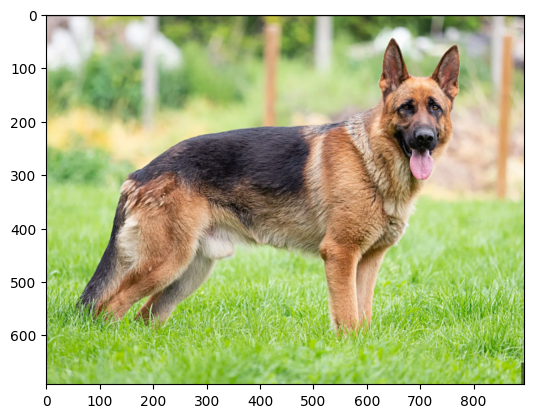

In [ ]:
# Verify the file path and make sure the file exists
image_path = '/content/Screenshot 2024-06-23 at 11.23.54 PM.png'
# If the above path is incorrect, change it to the actual path of the image

test_img = cv2.imread(image_path)

# Check if the image was loaded successfully
if test_img is None:
    print("Error: Could not read the image. Please check the file path and ensure the image file is valid.")
else:
    # Convert the image from BGR (OpenCV default) to RGB (Matplotlib default)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

    plt.imshow(test_img)
    plt.show()

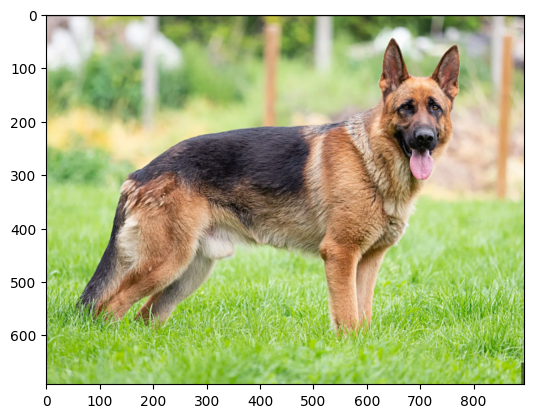

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img =cv2.resize(test_img,(256,256))

In [ ]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
y_pred=model.predict(test_input)

1/1 [==============================] - 0s 18ms/step


In [ ]:

  if y_pred[0][0] > 0.5:
    print("Dog")
  else:
    print("Cat")


Dog
